# 03 — Model Training: Logistic Regression Baseline

**Purpose**: establish the baseline that every comparative model (Random
Forest, XGBoost, SVM, LightGBM) is judged against. Per
`.claude/skills/machine-learning/SKILL.md`: "without a baseline, '92%
accuracy' from XGBoost means nothing."

No features are dropped or transformed here — this trains on the raw 20
features, following directly from `02_Preprocessing.ipynb`'s VIF finding
that no feature needs to be dropped.

Training/evaluation logic lives in `ml_pipeline/src/` (`src/models/`,
`src/evaluation/`, `src/experiments/`) so it is reusable by every later
comparative-model notebook and independently testable, rather than being
inline notebook-only code.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.evaluation.metrics import confusion_matrix_to_frame, evaluate_classifier
from src.experiments.logger import log_experiment
from src.models.baseline import train_logistic_regression_baseline

DATA_PATH = "../datasets/raw/student_stress_factors.csv"
EXPERIMENTS_DIR = "../experiments"
STRESS_LABEL_COL = "stress_level"
RANDOM_STATE = 42
TEST_SIZE = 0.2

## Load data and split

Stratified split, given the 3-class target — this preserves each class's
~33% share in both the train and test sets rather than letting a random
split skew the class balance by chance.

In [2]:
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[STRESS_LABEL_COL])
y = df[STRESS_LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train: (880, 20), Test: (220, 20)

Train class balance:
stress_level
0    0.340
2    0.335
1    0.325
Name: proportion, dtype: float64

Test class balance:
stress_level
0    0.336
2    0.336
1    0.327
Name: proportion, dtype: float64


## A note on scaling

**Does Logistic Regression need scaling?** In principle, yes, for two
reasons: (1) scikit-learn's `LogisticRegression` solvers are gradient-based
(default `lbfgs`), which converges more slowly and less reliably when
features span very different ranges; (2) L2 regularization (scikit-learn's
default) penalizes coefficient magnitude, so an unscaled feature with a
naturally larger range gets a systematically different regularization
effect than one with a small range — the penalty is not really comparing
features on equal footing. This dataset's features do span very different
ranges as-is: `sleep_quality` is 0-5, `anxiety_level` is 0-21, `self_esteem`
is 0-30 (see `01_EDA.ipynb`).

**This baseline is deliberately run unscaled anyway**, per the brief for
this notebook — the point of a first-pass baseline is a simple, honest
reference number, not the best possible Logistic Regression result. Tree-
based models (Random Forest, XGBoost, LightGBM) coming later are
scale-invariant and don't need this decision at all. Whether to add scaling
and re-run the Logistic Regression baseline (or keep this as the reference
point and treat a scaled version as a separate, later experiment) is left
as an open decision — not made here.

## Train baseline

In [3]:
model = train_logistic_regression_baseline(X_train, y_train, random_state=RANDOM_STATE)
model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Evaluate on the held-out test set

In [4]:
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)
class_labels = sorted(y.unique())
lr_metrics = evaluate_classifier(y_test, y_pred, y_score=y_score, labels=class_labels)

print(f"Accuracy:          {lr_metrics['accuracy']:.4f}")
print(f"Balanced accuracy: {lr_metrics['balanced_accuracy']:.4f}")
print(f"Precision (macro): {lr_metrics['precision_macro']:.4f}")
print(f"Recall (macro):    {lr_metrics['recall_macro']:.4f}")
print(f"F1 (macro):        {lr_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (macro, OvR): {lr_metrics['roc_auc_macro_ovr']:.4f}")

Accuracy:          0.8818
Balanced accuracy: 0.8821
Precision (macro): 0.8818
Recall (macro):    0.8821
F1 (macro):        0.8820
ROC-AUC (macro, OvR): 0.9851


        pred_0  pred_1  pred_2
true_0      63       5       6
true_1       3      66       3
true_2       7       2      65


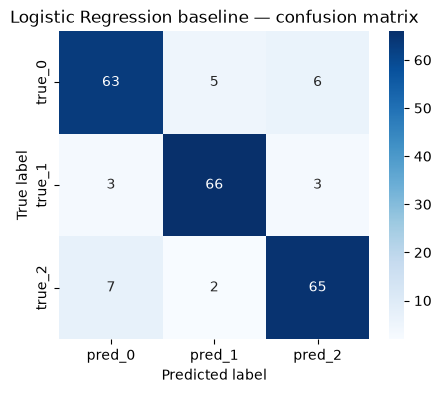

In [5]:
cm_frame = confusion_matrix_to_frame(lr_metrics["confusion_matrix"], class_labels)
print(cm_frame)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_frame, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression baseline — confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

## Log this experiment run

Per `IMPLEMENTATION_RULES.md`: every experiment run is logged, not just the
eventual winner, with model name, hyperparameters, all evaluation metrics,
and the dataset version used (a SHA-256 hash of the dataset file, in the
absence of formal data versioning).

In [6]:
log_path_lr = log_experiment(
    experiments_dir=EXPERIMENTS_DIR,
    experiment_name="baseline_logistic_regression",
    model_name=type(model).__name__,
    hyperparameters=model.get_params(),
    dataset_path=DATA_PATH,
    split_info={
        "test_size": TEST_SIZE,
        "stratify": True,
        "random_state": RANDOM_STATE,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
    },
    metrics=lr_metrics,
)
print(f"Logged to: {log_path_lr}")

Logged to: ../experiments/20260815T051616Z_baseline_logistic_regression.json


## Comparative Model Training

Trains Random Forest, XGBoost, SVM, and LightGBM against the same held-out
20% test set used for the Logistic Regression baseline above (no re-split),
so all five models are compared on identical data.

**Preprocessing decision — applied consistently, documented here explicitly:**
- **Random Forest, XGBoost, LightGBM are tree-based and scale-invariant**
  (they split on feature thresholds, not distances or gradients) — trained
  on the same raw, unscaled features as the baseline.
- **SVM is scale-sensitive** (it relies on distances between points) — it is
  trained via a `Pipeline(StandardScaler(), SVC())`, so the scaler is refit
  on each cross-validation fold's training portion only. It never sees a
  fold's validation data or the held-out test set, so there is no scaling
  leakage.

Each model is tuned via `GridSearchCV`/`RandomizedSearchCV` with stratified
5-fold cross-validation on the training split only, optimizing `f1_macro`
(consistent with this project's stated evaluation philosophy — never select
on accuracy alone). **No model is selected as a "winner" here** — that is a
separate, deliberate decision made after seeing the full comparison table.

In [7]:
from sklearn.model_selection import StratifiedKFold

from src.models.lightgbm_model import train_lightgbm_with_cv
from src.models.random_forest import train_random_forest_with_cv
from src.models.svm import train_svm_with_cv
from src.models.xgboost_model import train_xgboost_with_cv

# Stratified 5-fold CV, used identically for every comparison model's
# hyperparameter search, on the training split only (never on X_test).
CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV_SCORING = "f1_macro"

### Random Forest

In [8]:
# Trained on raw, unscaled X_train — Random Forest is scale-invariant.
rf_search = train_random_forest_with_cv(
    X_train, y_train, cv=CV_STRATEGY, random_state=RANDOM_STATE, scoring=CV_SCORING
)
print(f"Best params: {rf_search.best_params_}")
print(f"Best CV {CV_SCORING}: {rf_search.best_score_:.4f}")

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV f1_macro: 0.8808


Accuracy:             0.8864
Balanced accuracy:    0.8868
Precision (macro):    0.8882
Recall (macro):       0.8868
F1 (macro):           0.8861
ROC-AUC (macro, OvR): 0.9844

        pred_0  pred_1  pred_2
true_0      61       6       7
true_1       2      67       3
true_2       3       4      67


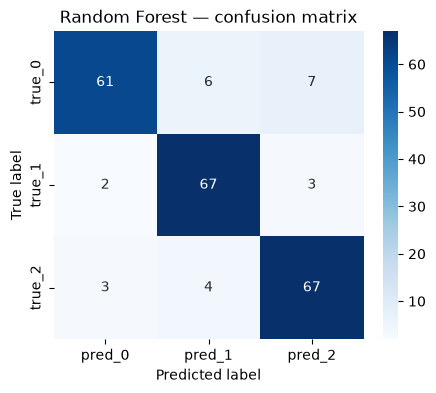

Logged to: ../experiments/20260815T051629Z_random_forest.json


In [9]:
rf_model = rf_search.best_estimator_
y_pred = rf_model.predict(X_test)
y_score = rf_model.predict_proba(X_test)
rf_metrics = evaluate_classifier(y_test, y_pred, y_score=y_score, labels=class_labels)

print(f"Accuracy:             {rf_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:    {rf_metrics['balanced_accuracy']:.4f}")
print(f"Precision (macro):    {rf_metrics['precision_macro']:.4f}")
print(f"Recall (macro):       {rf_metrics['recall_macro']:.4f}")
print(f"F1 (macro):           {rf_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (macro, OvR): {rf_metrics['roc_auc_macro_ovr']:.4f}")

cm_frame = confusion_matrix_to_frame(rf_metrics["confusion_matrix"], class_labels)
print()
print(cm_frame)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_frame, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest — confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

log_path_rf = log_experiment(
    experiments_dir=EXPERIMENTS_DIR,
    experiment_name="random_forest",
    model_name=type(rf_model).__name__,
    hyperparameters=rf_model.get_params(),
    dataset_path=DATA_PATH,
    split_info={
        "test_size": TEST_SIZE,
        "stratify": True,
        "random_state": RANDOM_STATE,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "cv_folds": CV_STRATEGY.get_n_splits(),
        "cv_scoring": CV_SCORING,
        "cv_best_score": rf_search.best_score_,
    },
    metrics=rf_metrics,
)
print(f"Logged to: {log_path_rf}")

### XGBoost

In [10]:
# Trained on raw, unscaled X_train — XGBoost is scale-invariant.
xgb_search = train_xgboost_with_cv(
    X_train, y_train, cv=CV_STRATEGY, random_state=RANDOM_STATE, scoring=CV_SCORING
)
print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV {CV_SCORING}: {xgb_search.best_score_:.4f}")

Best params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Best CV f1_macro: 0.8887


Accuracy:             0.8727
Balanced accuracy:    0.8729
Precision (macro):    0.8730
Recall (macro):       0.8729
F1 (macro):           0.8729
ROC-AUC (macro, OvR): 0.9682

        pred_0  pred_1  pred_2
true_0      62       6       6
true_1       4      64       4
true_2       7       1      66


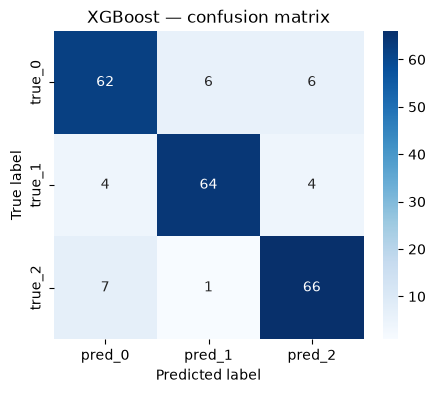

Logged to: ../experiments/20260815T051633Z_xgboost.json


In [11]:
xgb_model = xgb_search.best_estimator_
y_pred = xgb_model.predict(X_test)
y_score = xgb_model.predict_proba(X_test)
xgb_metrics = evaluate_classifier(y_test, y_pred, y_score=y_score, labels=class_labels)

print(f"Accuracy:             {xgb_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:    {xgb_metrics['balanced_accuracy']:.4f}")
print(f"Precision (macro):    {xgb_metrics['precision_macro']:.4f}")
print(f"Recall (macro):       {xgb_metrics['recall_macro']:.4f}")
print(f"F1 (macro):           {xgb_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (macro, OvR): {xgb_metrics['roc_auc_macro_ovr']:.4f}")

cm_frame = confusion_matrix_to_frame(xgb_metrics["confusion_matrix"], class_labels)
print()
print(cm_frame)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_frame, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost — confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

log_path_xgb = log_experiment(
    experiments_dir=EXPERIMENTS_DIR,
    experiment_name="xgboost",
    model_name=type(xgb_model).__name__,
    hyperparameters=xgb_model.get_params(),
    dataset_path=DATA_PATH,
    split_info={
        "test_size": TEST_SIZE,
        "stratify": True,
        "random_state": RANDOM_STATE,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "cv_folds": CV_STRATEGY.get_n_splits(),
        "cv_scoring": CV_SCORING,
        "cv_best_score": xgb_search.best_score_,
    },
    metrics=xgb_metrics,
)
print(f"Logged to: {log_path_xgb}")

### SVM

In [12]:
# X_train passed in raw/unscaled — scaling happens inside the Pipeline,
# refit per CV fold, so there is no leakage into validation folds or X_test.
svm_search = train_svm_with_cv(
    X_train, y_train, cv=CV_STRATEGY, random_state=RANDOM_STATE, scoring=CV_SCORING
)
print(f"Best params: {svm_search.best_params_}")
print(f"Best CV {CV_SCORING}: {svm_search.best_score_:.4f}")

/home/hp/miniconda3/envs/mainks/lib/python3.13/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'svc__estimator__kernel': 'linear', 'svc__estimator__C': 1}
Best CV f1_macro: 0.8776


Accuracy:             0.8864
Balanced accuracy:    0.8868
Precision (macro):    0.8868
Recall (macro):       0.8868
F1 (macro):           0.8860
ROC-AUC (macro, OvR): 0.9245

        pred_0  pred_1  pred_2
true_0      61       5       8
true_1       3      67       2
true_2       4       3      67


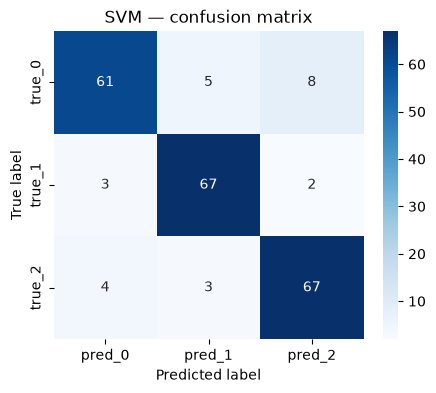

Logged to: ../experiments/20260815T051637Z_svm.json


In [13]:
svm_model = svm_search.best_estimator_  # full Pipeline(scaler, svc)
y_pred = svm_model.predict(X_test)  # pipeline applies the fitted scaler internally
y_score = svm_model.predict_proba(X_test)
svm_metrics = evaluate_classifier(y_test, y_pred, y_score=y_score, labels=class_labels)

print(f"Accuracy:             {svm_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:    {svm_metrics['balanced_accuracy']:.4f}")
print(f"Precision (macro):    {svm_metrics['precision_macro']:.4f}")
print(f"Recall (macro):       {svm_metrics['recall_macro']:.4f}")
print(f"F1 (macro):           {svm_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (macro, OvR): {svm_metrics['roc_auc_macro_ovr']:.4f}")

cm_frame = confusion_matrix_to_frame(svm_metrics["confusion_matrix"], class_labels)
print()
print(cm_frame)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_frame, annot=True, fmt="d", cmap="Blues")
plt.title("SVM — confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

log_path_svm = log_experiment(
    experiments_dir=EXPERIMENTS_DIR,
    experiment_name="svm",
    model_name=type(svm_model.named_steps["svc"]).__name__,
    hyperparameters=svm_model.get_params(),
    dataset_path=DATA_PATH,
    split_info={
        "test_size": TEST_SIZE,
        "stratify": True,
        "random_state": RANDOM_STATE,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "cv_folds": CV_STRATEGY.get_n_splits(),
        "cv_scoring": CV_SCORING,
        "cv_best_score": svm_search.best_score_,
    },
    metrics=svm_metrics,
)
print(f"Logged to: {log_path_svm}")

### LightGBM

In [14]:
# Trained on raw, unscaled X_train — LightGBM is scale-invariant.
lgbm_search = train_lightgbm_with_cv(
    X_train, y_train, cv=CV_STRATEGY, random_state=RANDOM_STATE, scoring=CV_SCORING
)
print(f"Best params: {lgbm_search.best_params_}")
print(f"Best CV {CV_SCORING}: {lgbm_search.best_score_:.4f}")

Best params: {'num_leaves': 31, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01}
Best CV f1_macro: 0.8945


Accuracy:             0.8727
Balanced accuracy:    0.8731
Precision (macro):    0.8731
Recall (macro):       0.8731
F1 (macro):           0.8726
ROC-AUC (macro, OvR): 0.9819

        pred_0  pred_1  pred_2
true_0      61       6       7
true_1       2      66       4
true_2       6       3      65


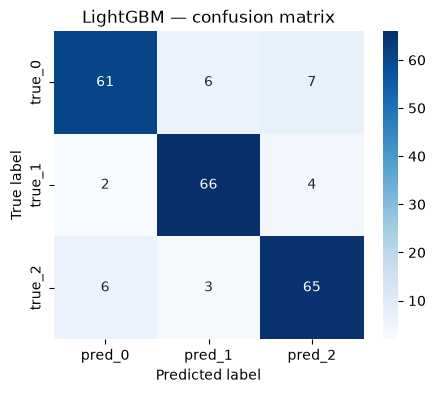

Logged to: ../experiments/20260815T051639Z_lightgbm.json


In [15]:
lgbm_model = lgbm_search.best_estimator_
y_pred = lgbm_model.predict(X_test)
y_score = lgbm_model.predict_proba(X_test)
lgbm_metrics = evaluate_classifier(y_test, y_pred, y_score=y_score, labels=class_labels)

print(f"Accuracy:             {lgbm_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:    {lgbm_metrics['balanced_accuracy']:.4f}")
print(f"Precision (macro):    {lgbm_metrics['precision_macro']:.4f}")
print(f"Recall (macro):       {lgbm_metrics['recall_macro']:.4f}")
print(f"F1 (macro):           {lgbm_metrics['f1_macro']:.4f}")
print(f"ROC-AUC (macro, OvR): {lgbm_metrics['roc_auc_macro_ovr']:.4f}")

cm_frame = confusion_matrix_to_frame(lgbm_metrics["confusion_matrix"], class_labels)
print()
print(cm_frame)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_frame, annot=True, fmt="d", cmap="Blues")
plt.title("LightGBM — confusion matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

log_path_lgbm = log_experiment(
    experiments_dir=EXPERIMENTS_DIR,
    experiment_name="lightgbm",
    model_name=type(lgbm_model).__name__,
    hyperparameters=lgbm_model.get_params(),
    dataset_path=DATA_PATH,
    split_info={
        "test_size": TEST_SIZE,
        "stratify": True,
        "random_state": RANDOM_STATE,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "cv_folds": CV_STRATEGY.get_n_splits(),
        "cv_scoring": CV_SCORING,
        "cv_best_score": lgbm_search.best_score_,
    },
    metrics=lgbm_metrics,
)
print(f"Logged to: {log_path_lgbm}")

## Summary comparison table

All five models, side by side, on the identical held-out test set. Presented
in training order — **not** sorted or ranked by any metric, since no model
is selected here.

In [16]:
def _metrics_row(name: str, metrics_dict: dict, best_params=None) -> dict:
    row = {"model": name}
    row.update({k: v for k, v in metrics_dict.items() if k != "confusion_matrix"})
    row["best_params"] = best_params if best_params is not None else "default (first-pass baseline, no tuning)"
    return row


comparison_rows = [
    _metrics_row("Logistic Regression (baseline)", lr_metrics),
    _metrics_row("Random Forest", rf_metrics, rf_search.best_params_),
    _metrics_row("XGBoost", xgb_metrics, xgb_search.best_params_),
    _metrics_row("SVM", svm_metrics, svm_search.best_params_),
    _metrics_row("LightGBM", lgbm_metrics, lgbm_search.best_params_),
]
comparison_table = pd.DataFrame(comparison_rows).set_index("model")
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro_ovr"]
comparison_table[metric_cols] = comparison_table[metric_cols].round(4)
comparison_table

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,best_params
model,,,,,,,
Logistic Regression (baseline),0.8818,0.882132,0.8818,0.8821,0.8820,0.9851,"default (first-pass baseline, no tuning)"
Random Forest,0.8864,0.886762,0.8882,0.8868,0.8861,0.9844,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
XGBoost,0.8727,0.872873,0.8730,0.8729,0.8729,0.9682,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
SVM,0.8864,0.886762,0.8868,0.8868,0.8860,0.9245,"{'svc__estimator__kernel': 'linear', 'svc__est..."
LightGBM,0.8727,0.873123,0.8731,0.8731,0.8726,0.9819,"{'num_leaves': 31, 'n_estimators': 100, 'max_d..."


**No model has been selected.** Per `CLAUDE.md`, model selection must not
rest on accuracy alone — that is a separate, deliberate decision to make
once these numbers have been reviewed together.

## Artifact export — selected model

Random Forest has been selected as the final model (see
`docs/research/methodology.md` § Model Selection for the full reasoning —
selection was **not** made on accuracy alone).

Per `IMPLEMENTATION_RULES.md`, artifacts are written to
`ml_pipeline/artifacts/` with a version-stamped filename, and this is the
only place a model is ever trained — `backend/app/` loads these artifacts
and never fits anything itself.

**On fitted preprocessing objects**: there are none to export for this model.
Random Forest is scale-invariant and was trained on the raw 20 features with
no scaling, no encoding (all features are already numeric/ordinal), and no
imputation (the dataset has zero missing values — see `01_EDA.ipynb`). The
`StandardScaler` used elsewhere in this notebook belongs to the SVM pipeline
only and is deliberately **not** exported, since it is not part of the
selected model. `feature_schema.json` therefore carries the full
preprocessing contract the backend needs: exact feature names, their order,
and their expected ranges.

In [17]:
import json
from datetime import datetime, timezone

import joblib

from src.experiments.logger import hash_file

ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_VERSION = "v1"

# --- 1. The trained model itself (gitignored — binary, reproducible from this notebook) ---
model_filename = f"stress_model_{MODEL_VERSION}.pkl"
joblib.dump(rf_model, ARTIFACTS_DIR / model_filename)
print(f"Saved model: {ARTIFACTS_DIR / model_filename}")

Saved model: ../artifacts/stress_model_v1.pkl


In [18]:
# --- 2. feature_schema.json: the contract backend/app/ml must satisfy when
#        building a feature vector for inference. Column ORDER matters —
#        scikit-learn models are positional, so a reordered vector silently
#        produces wrong predictions rather than an error.
feature_schema = {
    "model_version": MODEL_VERSION,
    "target": {
        "name": STRESS_LABEL_COL,
        "classes": [int(c) for c in class_labels],
        "class_meaning": {"0": "low", "1": "moderate", "2": "high"},
    },
    "n_features": int(X.shape[1]),
    "features": [
        {
            "name": col,
            "position": int(i),
            "dtype": str(X[col].dtype),
            "min": int(X[col].min()),
            "max": int(X[col].max()),
        }
        for i, col in enumerate(X.columns)
    ],
    "preprocessing": {
        "scaling": "none — Random Forest is scale-invariant; features used raw",
        "encoding": "none — all features already numeric/ordinal in the source dataset",
        "imputation": "none — source dataset has zero missing values",
    },
}

schema_path = ARTIFACTS_DIR / "feature_schema.json"
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, indent=2)
print(f"Saved schema: {schema_path}")
print(f"{feature_schema['n_features']} features, target classes {feature_schema['target']['classes']}")

Saved schema: ../artifacts/feature_schema.json
20 features, target classes [0, 1, 2]


In [19]:
# --- 3. artifact_manifest.json: small, committed metadata describing what was
#        exported, when, from which dataset, and with what measured performance.
#        The .pkl is gitignored, so this manifest is the tracked record of it.
manifest = {
    "model_version": MODEL_VERSION,
    "created_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "selected_model": type(rf_model).__name__,
    "selection_rationale_doc": "docs/research/methodology.md § Model Selection",
    "artifacts": {
        "model": {
            "filename": model_filename,
            "sha256": hash_file(ARTIFACTS_DIR / model_filename),
            "committed": False,
            "note": "gitignored binary; regenerate by re-running 03_ModelTraining.ipynb",
        },
        "feature_schema": {"filename": "feature_schema.json", "committed": True},
    },
    "training_dataset": {
        "path": DATA_PATH,
        "sha256": hash_file(DATA_PATH),
        "rows": int(len(df)),
    },
    "hyperparameters": rf_search.best_params_,
    "validation": {
        "cv": f"StratifiedKFold(n_splits={CV_STRATEGY.get_n_splits()}, shuffle=True, random_state={RANDOM_STATE})",
        "cv_scoring": CV_SCORING,
        "cv_best_score": float(rf_search.best_score_),
        "holdout_test_size": TEST_SIZE,
        "holdout_test_rows": int(len(X_test)),
        "external_validation": "not yet performed — planned for Phase 8",
    },
    "holdout_test_metrics": {
        k: float(v) for k, v in rf_metrics.items() if k != "confusion_matrix"
    },
}

manifest_path = ARTIFACTS_DIR / "artifact_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)
print(f"Saved manifest: {manifest_path}")
print(json.dumps(manifest, indent=2))

Saved manifest: ../artifacts/artifact_manifest.json
{
  "model_version": "v1",
  "created_utc": "2026-08-15T05:16:39Z",
  "selected_model": "RandomForestClassifier",
  "selection_rationale_doc": "docs/research/methodology.md \u00a7 Model Selection",
  "artifacts": {
    "model": {
      "filename": "stress_model_v1.pkl",
      "sha256": "a5f9fe7f57d39318eef33ad293308965936c011964fc43327a35ca70ba274e6f",
      "committed": false,
      "note": "gitignored binary; regenerate by re-running 03_ModelTraining.ipynb"
    },
    "feature_schema": {
      "filename": "feature_schema.json",
      "committed": true
    }
  },
  "training_dataset": {
    "path": "../datasets/raw/student_stress_factors.csv",
    "sha256": "14a45e92708b0c063ad4ab04563aa8fd4e3fc27157fd282e1c0658dc5161faed",
    "rows": 1100
  },
  "hyperparameters": {
    "max_depth": 10,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "n_estimators": 100
  },
  "validation": {
    "cv": "StratifiedKFold(n_splits=5, shuffl